---
title: "The bijector menu for coupling"
short_title: "01 · Bijector menu"
subtitle: "Affine, mixture-CDF, deep-sigmoid, rational-quadratic spline — the per-coordinate transforms a coupling layer can wrap, and what each buys"
description: >
  The coupling pattern works for any monotone bijector T. This notebook tours the
  gauss_flows menu — affine (RealNVP), mixture-CDF, deep-sigmoid, and the
  rational-quadratic spline (NSF) — visualising each as a 1-D map, showing affine is
  linear while the others bend, and comparing their expressiveness on a spiral where
  the spline and mixture-CDF win.
---

(sec-nb-cpl-01)=
# 01 — The bijector menu for coupling

[Notebook 00](00_coupling_pattern.ipynb) showed the coupling contract — triangular
Jacobian, free log-det, analytic inverse — holds for **any** elementwise monotone
bijector $T$. The bijector and the conditioner are *independent* choices: this
notebook fixes the conditioner (a small MLP) and tours the **$T$ menu** that
`gauss_flows` offers. The choice sets how much each coupling layer can bend a
coordinate.

| bijector | $T(x_B)$ | inverse | lineage |
|---|---|---|---|
| **affine** | $s\,x_B + t$ | closed form | RealNVP {cite}`dinh2017realnvp` |
| **mixture-CDF** | $\Phi^{-1}\!\big(\sum_k\pi_k\Phi(x_B;\mu_k,\sigma_k)\big)$ | root-find | Part 1 [01](../01_marginal_transforms/01_kde_mixture_cdf.ipynb) |
| **deep-sigmoid** | cascaded $\sigma$-shifts | root-find | NAF-style |
| **RQ-spline** | piecewise rational-quadratic | closed form | NSF {cite}`durkan2019nsf` |

**What you will see**

- Each bijector as a **1-D map** of the active coordinate — affine is a straight
  line, the rest are monotone *curves*.
- The **family** of maps the conditioner can dial: affine can only pick a line;
  expressive bijectors pick arbitrary monotone shapes.
- An **expressiveness** comparison on a spiral: the spline and mixture-CDF fit best.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import optax
from flowjax.bijections import Chain, Flip, Invert
from flowjax.distributions import Normal, Transformed

import gauss_flows as gf
from gauss_flows._src.transforms.bijections.linear.rotation import HouseholderRotation
from _style import GAUSS_KW, SCATTER_KW, style_ax

jax.config.update("jax_enable_x64", True)

# Builders for each coupling bijector, with a shared small MLP conditioner.
COUPLINGS = {
    "affine": (gf.AffineCoupling, {}),
    "mixture-CDF": (gf.MixtureGaussianCDFCoupling, {"n_components": 8}),
    "deep-sigmoid": (gf.DeepSigmoidCoupling, {"n_components": 8}),
    "RQ-spline": (gf.RQSplineCoupling, {"n_bins": 8, "interval": 4.0}),
}
COLORS = {"affine": "tab:red", "mixture-CDF": "tab:blue",
          "deep-sigmoid": "tab:purple", "RQ-spline": "tab:green"}


def make_coupling(name, key):
    cls, kw = COUPLINGS[name]
    return cls(key, shape=(2,), nn_width=32, nn_depth=2, **kw)

## 1. Each bijector is a per-coordinate monotone map

In a 2-D coupling the active coordinate $x_1$ is transformed conditioned on the
passive $x_0$. Fix $x_0$ and sweep $x_1$: the bijector traces a 1-D monotone map
$x_1 \mapsto z_1$. Its *shape* is the bijector's expressiveness.

nonlinearity (max deviation from a straight line):


  affine       : 0.000


  mixture-CDF  : 0.258


  deep-sigmoid : 0.750


  RQ-spline    : 0.151


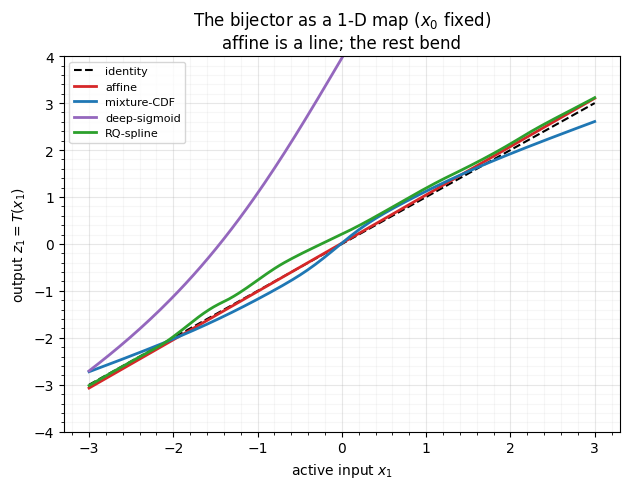

In [2]:
xb = np.linspace(-3, 3, 200)
x0 = 0.7
fig, ax = plt.subplots(figsize=(6.4, 5.0))
ax.plot([-3, 3], [-3, 3], **GAUSS_KW, label="identity")
print("nonlinearity (max deviation from a straight line):")
for name in COUPLINGS:
    b = make_coupling(name, jr.key(3))
    zb = np.array([float(b.transform(jnp.array([x0, x]))[1]) for x in xb])
    p = np.polyfit(xb, zb, 1)
    nonlin = float(np.abs(zb - np.polyval(p, xb)).max())
    print(f"  {name:13s}: {nonlin:.3f}")
    ax.plot(xb, zb, color=COLORS[name], lw=2, label=f"{name}")
ax.set(title="The bijector as a 1-D map ($x_0$ fixed)\naffine is a line; the rest bend",
       xlabel="active input $x_1$", ylabel="output $z_1 = T(x_1)$", ylim=(-4, 4))
ax.legend(fontsize=8); style_ax(ax)
fig.tight_layout()

**Affine is a straight line** — a coupling layer with an affine $T$ can only
*scale and shift* a coordinate (nonlinearity $\approx 0$). The mixture-CDF and
rational-quadratic spline bend into smooth monotone S-curves; the deep-sigmoid
bends most aggressively (and can get steep). All stay monotone — they must, to be
invertible.

## 2. Expressiveness is the *family* of maps the conditioner can dial

The conditioner reads $x_0$ and emits $T$'s parameters, so as $x_0$ varies the
layer sweeps a whole **family** of 1-D maps. That family is the layer's true
capacity. For affine the family is all *lines* (the conditioner only picks slope
and intercept); for the spline it is a family of arbitrary monotone curves.

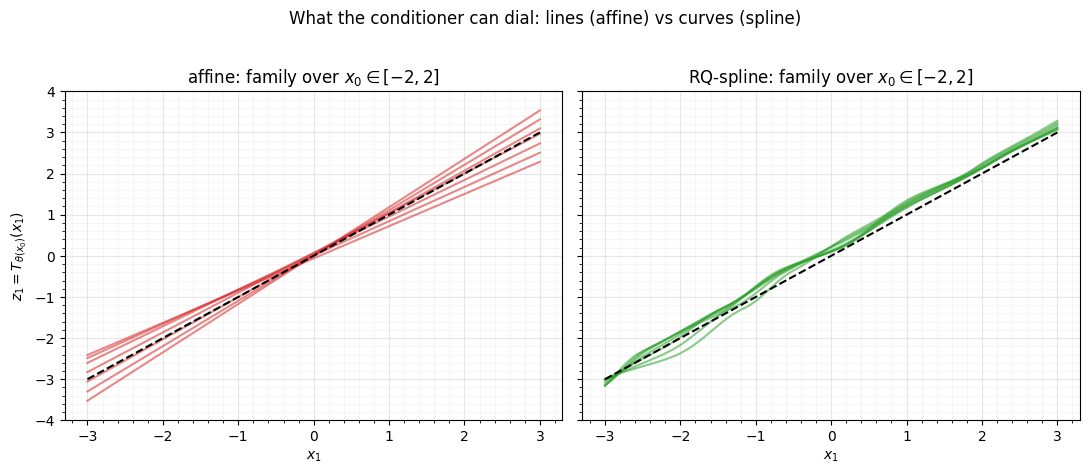

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharex=True, sharey=True)
for ax, name in zip(axes, ["affine", "RQ-spline"]):
    b = make_coupling(name, jr.key(3))
    for x0v in np.linspace(-2, 2, 7):
        zb = np.array([float(b.transform(jnp.array([x0v, x]))[1]) for x in xb])
        ax.plot(xb, zb, color=COLORS[name], lw=1.5, alpha=0.55)
    ax.plot([-3, 3], [-3, 3], **GAUSS_KW)
    ax.set(title=f"{name}: family over $x_0\\in[-2,2]$", xlabel="$x_1$", ylim=(-4, 4))
    style_ax(ax)
axes[0].set_ylabel("$z_1 = T_{\\theta(x_0)}(x_1)$")
fig.suptitle("What the conditioner can dial: lines (affine) vs curves (spline)", y=1.02)
fig.tight_layout()

The affine panel is a sheaf of straight lines — every coordinate map the layer can
produce is linear, so non-linear dependence must be built up across many stacked
layers. The spline panel is a sheaf of distinct curves: a *single* layer can model
a non-linear, context-dependent transform. That is why expressive bijectors need
fewer layers.

## 3. Expressiveness in practice

We make this concrete: fit a small flow (**2 coupling blocks**) with each bijector
on a spiral and compare held-out log-likelihood. With so few blocks, the
per-bijector expressiveness — not depth — decides the fit.

affine       : log p = -2.307


mixture-CDF  : log p = -1.663


deep-sigmoid : log p = -2.432


RQ-spline    : log p = -1.625


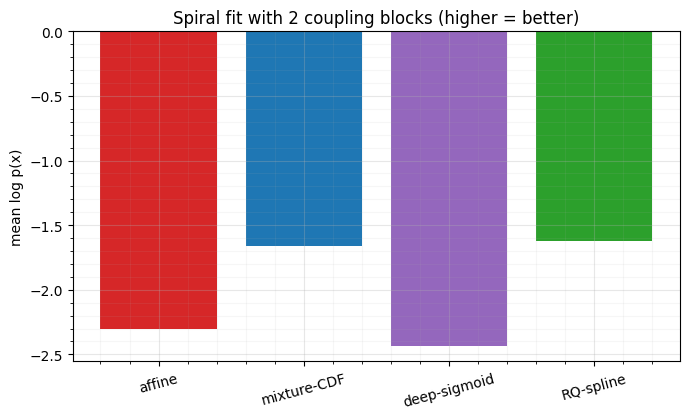

In [4]:
rng = np.random.default_rng(0)
n = 4500
t = rng.uniform(0.5, 3.5, n)
arm = (rng.integers(0, 2, n) * 2 - 1)[:, None]
xy = arm * np.stack([t * np.cos(2.5 * t), t * np.sin(2.5 * t)], axis=1) + 0.08 * rng.standard_normal((n, 2))
xy = (xy - xy.mean(0)) / xy.std(0)
# Disjoint train / eval so the bar chart is genuine held-out likelihood.
X_train = jnp.asarray(xy[:3000])
X_eval = jnp.asarray(xy[3000:])
X = X_train  # plotting alias


def build_flow(name, key, n_blocks=2):
    bijections = []
    for k in jr.split(key, n_blocks):
        rk, c1, c2 = jr.split(k, 3)
        rot = HouseholderRotation(n_reflections=2, shape=(2,))
        rot = eqx.tree_at(lambda r: r.params, rot, jr.normal(rk, rot.params.shape))
        bijections += [rot, make_coupling(name, c1), Flip(shape=(2,)),
                       make_coupling(name, c2), Flip(shape=(2,))]
    return Transformed(Normal(jnp.zeros(2)), Invert(Chain(bijections)))


def train(flow, steps=1500, peak_lr=3e-3, batch=512, seed=1):
    params, static = eqx.partition(flow, eqx.is_inexact_array)
    schedule = optax.cosine_onecycle_schedule(steps, peak_lr)
    opt = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(schedule))
    state = opt.init(params)

    @eqx.filter_jit
    def step(params, state, xb):
        loss, g = eqx.filter_value_and_grad(
            lambda p: -jnp.mean(jax.vmap(eqx.combine(p, static).log_prob)(xb)))(params)
        upd, state = opt.update(g, state)
        return eqx.apply_updates(params, upd), state, loss

    key = jr.key(seed)
    for _ in range(steps):
        key, sk = jr.split(key)
        params, state, _ = step(params, state, X_train[jr.randint(sk, (batch,), 0, X_train.shape[0])])
    return eqx.combine(params, static)


logp = lambda f: float(jax.vmap(f.log_prob)(X_eval).mean())
fitted = {name: train(build_flow(name, jr.key(0))) for name in COUPLINGS}
for name, f in fitted.items():
    print(f"{name:13s}: log p = {logp(f):.3f}")

fig, ax = plt.subplots(figsize=(7.0, 4.3))
names = list(COUPLINGS)
ax.bar(names, [logp(fitted[n]) for n in names], color=[COLORS[n] for n in names])
ax.set(title="Spiral fit with 2 coupling blocks (higher = better)",
       ylabel="mean log p(x)")
ax.tick_params(axis="x", labelrotation=15); style_ax(ax)
fig.tight_layout()

The **rational-quadratic spline** and **mixture-CDF** fit the spiral best — their
expressive per-coordinate curves capture the bend in just two blocks. **Affine**
lags: linear per-coordinate maps need more depth to compose the same shape.
**Deep-sigmoid** is expressive in principle (its 1-D map bent the most in §1) but
its steep, unbounded maps make it the hardest to optimise here — a reminder that
raw flexibility is not the same as trainability. We compare the weakest and
strongest densities.

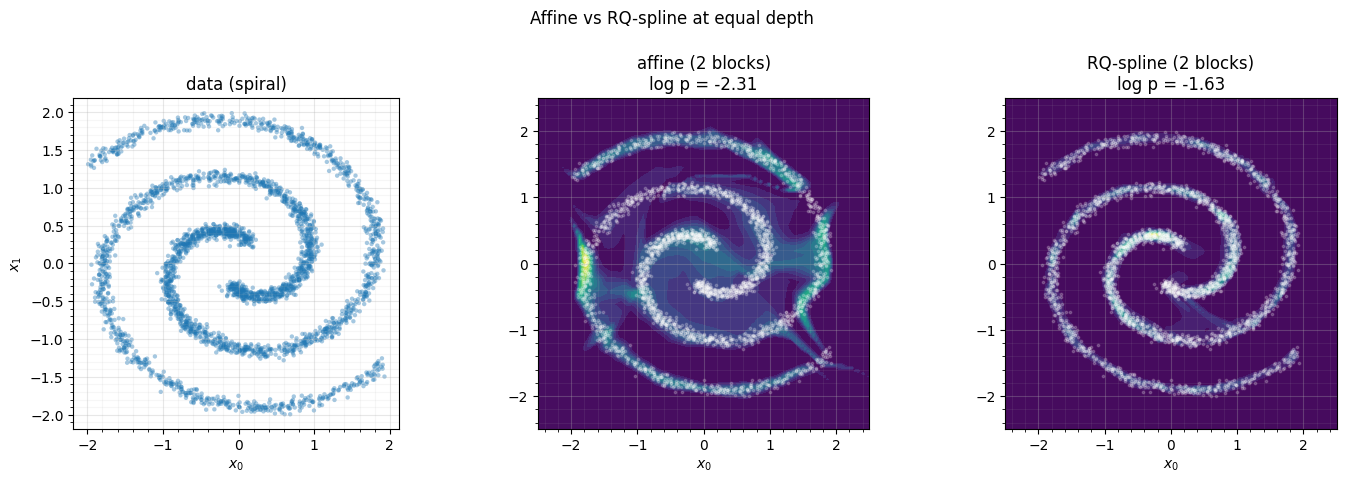

In [5]:
gx, gy = np.meshgrid(np.linspace(-2.5, 2.5, 120), np.linspace(-2.5, 2.5, 120))
grid = jnp.asarray(np.column_stack([gx.ravel(), gy.ravel()]))
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.6))
axes[0].scatter(X[:, 0], X[:, 1], color="tab:blue", **SCATTER_KW)
axes[0].set(title="data (spiral)", xlabel="$x_0$", ylabel="$x_1$")
for ax, name in zip(axes[1:], ["affine", "RQ-spline"]):
    lp = np.asarray(jax.vmap(fitted[name].log_prob)(grid)).reshape(gx.shape)
    ax.contourf(gx, gy, np.exp(lp), levels=18, cmap="viridis")
    ax.scatter(X[:, 0], X[:, 1], s=3, color="white", alpha=0.2)
    ax.set(title=f"{name} (2 blocks)\nlog p = {logp(fitted[name]):.2f}", xlabel="$x_0$")
for ax in axes:
    ax.set_aspect("equal"); style_ax(ax)
fig.suptitle("Affine vs RQ-spline at equal depth", y=1.02)
fig.tight_layout()

## Recap

| bijector | per-coordinate map | inverse | notes |
|---|---|---|---|
| **affine** | linear ($s\,x+t$) | closed form | cheapest; RealNVP; needs depth for non-linearity |
| **mixture-CDF** | smooth monotone S | root-find | reuses Part 1's marginal; analytic log-det |
| **deep-sigmoid** | cascaded $\sigma$ | root-find | very flexible, but steep & harder to train |
| **RQ-spline** | piecewise rational-quadratic | **closed form** | NSF; expressive *and* exactly invertible — the modern default |

The bijector sets per-layer expressiveness; the spline's closed-form inverse and
analytic log-det (Part 1 [02](../01_marginal_transforms/02_spline_cdf.ipynb)) make
it the usual choice. But the *other* half of a coupling layer — the **conditioner**
— is where most of the modelling power lives.

**Next up.** [02 — Conditioner architectures](02_conditioner_architectures.ipynb):
the network that reads $x_A$ and emits $\theta$ is the expressive engine; we tour
MLP / shared-MLP / ResNet conditioners, output clamping for stability, and the
parameter-budget-vs-expressiveness trade-off.